In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('Student Social Media And Mental Health Impact (1).csv')

In [4]:
df.shape

(5000, 13)

In [5]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [6]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

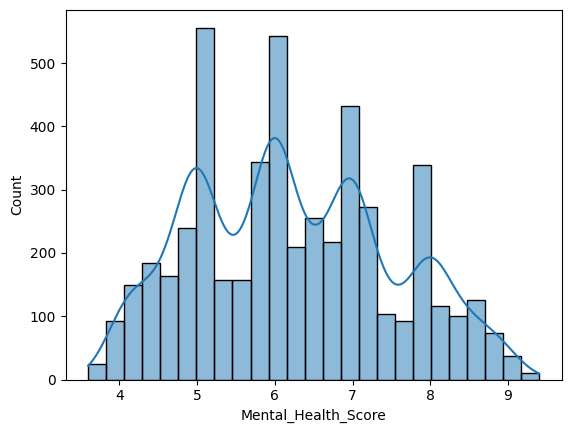

In [11]:
sns.histplot(df['Mental_Health_Score'],kde = True)

<Axes: >

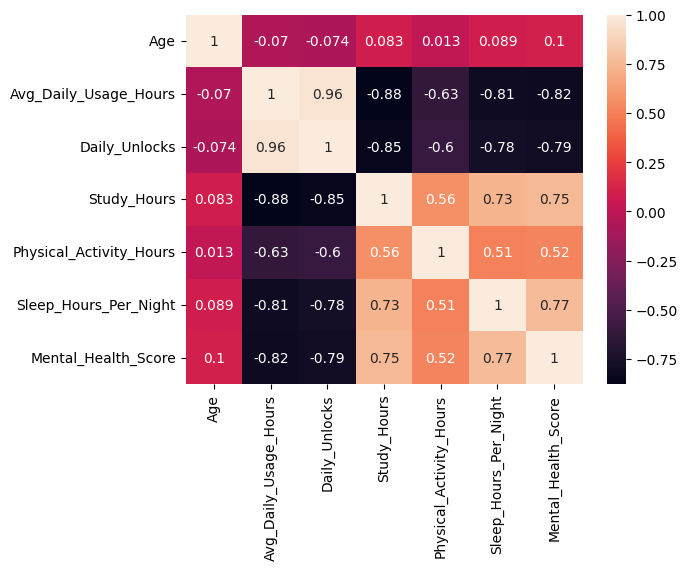

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot = True)

In [13]:
df['Stress_Level'].unique()
order = ['Low','Medium','High','Very High']

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

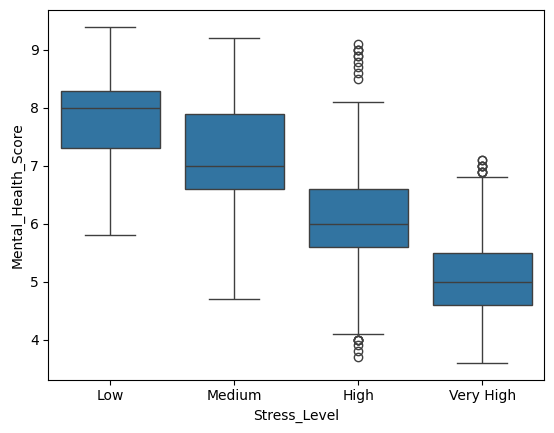

In [14]:
sns.boxplot(x = df['Stress_Level'], y = df['Mental_Health_Score'],order = order)

In [15]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

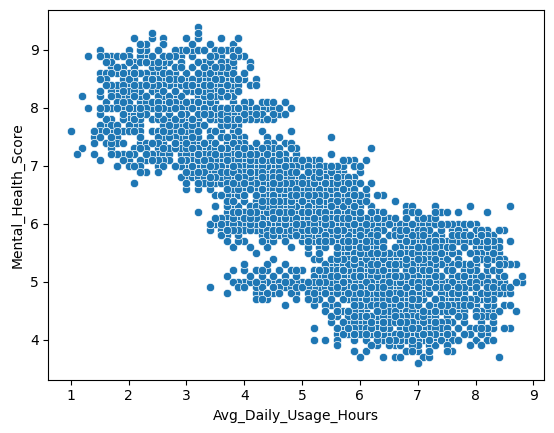

In [16]:
sns.scatterplot(x = df['Avg_Daily_Usage_Hours'],y = df['Mental_Health_Score'])

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

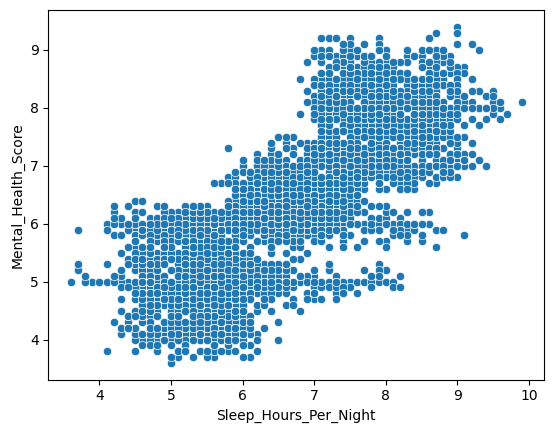

In [17]:
sns.scatterplot(x = df['Sleep_Hours_Per_Night'], y = df['Mental_Health_Score'])

In [18]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [19]:
platform_counts = df['Most_Used_Platform'].value_counts()

<Axes: xlabel='count', ylabel='Most_Used_Platform'>

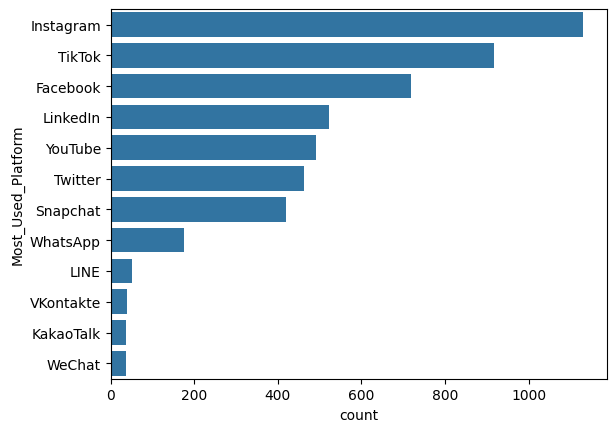

In [20]:
sns.countplot(df['Most_Used_Platform'],order = platform_counts.index)

In [21]:
num_features = df.select_dtypes(include = 'number')


In [22]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)

In [23]:
outliers.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

In [24]:
df = df.drop_duplicates()

In [25]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower = 0)

In [26]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [27]:
num_features = df.select_dtypes(include = 'number')
num_features.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [49]:
top_countries = df["Country"].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [29]:
def group_country(country):
    if country in top_countries:
        return country
    elif country not in top_countries:
        return 'Other'

In [30]:
df['Grouped_Countries'] = df['Country'].apply(group_country)

In [31]:
df['Grouped_Countries'].value_counts()

Grouped_Countries
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [32]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_Countries
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [33]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_Countries'],
      dtype='object')

In [34]:
from sklearn.model_selection import train_test_split

other_numeric_col = ['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours','Sleep_Hours_Per_Night',]

skewed_col = ['Study_Hours']

onehot_col = ['Gender','Country','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Grouped_Countries']

ordinal_col = ['Stress_Level']

feature_col = other_numeric_col + skewed_col + onehot_col + ordinal_col

X = df[feature_col]
y = df["Mental_Health_Score"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [35]:
X

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Physical_Activity_Hours,Sleep_Hours_Per_Night,Study_Hours,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Grouped_Countries,Stress_Level
0,21,4.0,134,2.2,6.7,4.5,Male,Other,Undergraduate,Facebook,Networking,Other,Medium
1,23,1.6,73,2.4,8.6,7.0,Female,Other,Graduate,LinkedIn,Education,Other,Low
2,22,4.6,166,1.8,6.7,4.0,Male,Canada,Undergraduate,Instagram,Entertainment,Canada,Medium
3,18,7.0,220,1.7,5.4,1.0,Male,Other,High School,Snapchat,Entertainment,Other,Very High
4,24,7.5,237,1.1,5.0,1.0,Female,Other,Graduate,Facebook,Networking,Other,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,1.9,89,2.2,7.9,6.1,Female,Other,High School,YouTube,Education,Other,Low
4996,18,6.6,216,1.8,6.0,2.3,Female,Other,High School,YouTube,Education,Other,Very High
4997,19,3.8,151,1.4,7.5,5.4,Female,India,Undergraduate,LinkedIn,Education,India,Medium
4998,18,3.8,119,1.5,6.4,4.0,Male,Other,High School,Instagram,Entertainment,Other,Medium


In [36]:
#skewed pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, FunctionTransformer,OneHotEncoder
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])

numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low','Medium','High','Very High']])),
])

onehot_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('skewed_pipepline',skew_pipeline,skewed_col),
    ('numeric_pipeline',numeric_pipeline,other_numeric_col),
    ('ordinal_pipeline',ordinal_pipeline,ordinal_col),
    ('onehot_pipeline',onehot_pipeline,onehot_col)
])

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('linear_regression',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_training = lr_pipeline.predict(X_train)
lr_r2 = r2_score(y_test,lr_pred)
lr_r2_training = r2_score(y_train,lr_pred_training)
lr_mae = mean_absolute_error(y_test,lr_pred)


print(f"the test accuracy= {lr_r2}")
print(f"the test accuracy= {lr_r2_training}")
print(f"the MAE accuracy= {lr_mae}")

the test accuracy= 0.7866985653053776
the test accuracy= 0.7800764399374713
the MAE accuracy= 0.47871434560567383


In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random_forrest',RandomForestRegressor())
])

rf_pipeline.fit(X_train,y_train)
rf_predict = rf_pipeline.predict(X_test)
rf_predict_training = rf_pipeline.predict(X_train)

rf_r2 = r2_score(y_test,rf_predict)
rf_r2_training = r2_score(y_train,rf_predict_training)

rf_mae = mean_absolute_error(y_test,rf_predict)

print(f"The rf score for testing = {rf_r2}")
print(f"The rf score for training = {rf_r2_training}")
print(f"The mae for testing = {rf_mae}")

The rf score for testing = 0.9112700950421807
The rf score for training = 0.9860834724977123
The mae for testing = 0.2859374666666668


In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random_forrest__n_estimators'      : [100, 200, 300],
    'random_forrest__max_depth'        : [5, 10, 15],
    'random_forrest__min_samples_split': [2, 5, 10],
    'random_forrest__min_samples_leaf' : [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random_forrest__max_depth': [5, 10, ...], 'random_forrest__min_samples_leaf': [1, 2, ...], 'random_forrest__min_samples_split': [2, 5, ...], 'random_forrest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the va

In [ ]:
import joblib

joblib.dump(rf_pipeline,'Mental_Health_Score.pkl')

['Mental_Health_Score.pkl']

In [48]:
 df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_Countries']

In [56]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [59]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [60]:
y.describe()

count    4998.000000
mean        6.231152
std         1.278476
min         3.600000
25%         5.100000
50%         6.100000
75%         7.100000
max         9.400000
Name: Mental_Health_Score, dtype: float64